# Set-Up

In [1]:
%uv pip install monai torch
!pip install monai
!pip install nibabel --break-system-packages
!pip install itk --break-system-packages
!pip install matplotlib

Using Python 3.12.6 environment at: /usr/local
Resolved 27 packages in 778ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
Prepared 1 package in 220ms
Installed 1 package in 313ms
 + monai==1.5.2
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [60]:
!pip freeze

absl-py==2.3.1
accelerate==1.10.1
aiofiles==24.1.0
aiohappyeyeballs==2.4.3
aiohttp==3.10.8
aiosignal==1.3.1
altair==5.5.0
annotated-types==0.7.0
anthropic==0.66.0
anyio==4.10.0
asttokens==3.0.0
asyncpg==0.30.0
attrs==24.2.0
Authlib==1.6.3
awscrt==0.27.6
basedpyright==1.31.4
beautifulsoup4==4.13.5
bokeh==3.8.0
boto3==1.40.23
botocore==1.40.23
cbor2==6.1.1
certifi==2024.8.30
cffi==1.17.1
charset-normalizer==3.4.3
chex==0.1.90
click==8.2.1
comm==0.2.3
contourpy==1.3.3
cryptography==45.0.7
cycler==0.12.1
debugpy==1.8.16
decorator==5.2.1
diffusers==0.35.1
distro==1.9.0
dm-sonnet==2.0.2
dm-tree==0.1.9
etils==1.13.0
executing==2.2.1
fastapi==0.116.1
fastjsonschema==2.21.2
filelock==3.13.1
flax==0.11.2
fonttools==4.59.2
frozenlist==1.4.1
fsspec==2024.6.1
ftfy==6.3.1
greenlet==3.2.4
grpcio==1.74.0
grpclib==0.4.7
h11==0.16.0
h2==4.1.0
h5py==3.14.0
hf-xet==1.1.9
hpack==4.0.0
httpcore==1.0.9
httptools==0.7.1
httpx==0.28.1
huggingface-hub==0.34.4
humanize==4.13.0
hyperframe==6.0.1
idna==3.10
imagei

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from monai.apps import DecathlonDataset

from monai.losses import DiceLoss
from monai.metrics import DiceMetric

from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    EnsureTyped,
    EnsureChannelFirstd,
    Resized
)
import time
from monai.data import DataLoader, decollate_batch
from monai.inferers import sliding_window_inference
from monai.networks.blocks import PatchEmbeddingBlock

# Modules

In [3]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None, last_relu=False):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv3d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv3d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True) if last_relu else nn.LeakyReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

In [4]:
class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels_from_down_path, skip_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2,
                                  mode='trilinear',
                                  align_corners=True)
            # The DoubleConv should take in_channels_from_down_path (x1) + skip_channels (x2) as its input
            # After upsampling, x1 still has in_channels_from_down_path
            self.conv = DoubleConv(in_channels_from_down_path + skip_channels, out_channels, (in_channels_from_down_path + skip_channels) // 2)
        else:
            # If not bilinear, transposed conv halves channels of x1.
            self.up = nn.ConvTranspose3d(
                in_channels_from_down_path,
                in_channels_from_down_path // 2,
                kernel_size=2,
                stride=2,
            )
            # Then concatenate with skip_channels.
            self.conv = DoubleConv(in_channels_from_down_path // 2 + skip_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHWD
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        diffZ = x2.size()[4] - x1.size()[4]

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2,
             diffZ // 2, diffZ - diffZ // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

In [5]:

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels, last_relu=False):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool3d(2),
            DoubleConv(in_channels, out_channels, last_relu=last_relu),
        )

    def forward(self, x):
        return self.maxpool_conv(x)

In [6]:

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, channel, spatial_dims, patch_size, hidden):
        super(MultiHeadSelfAttention, self).__init__()
        #self.query = MultiHeadDense(channel, bias=False)
        #self.key = MultiHeadDense(channel, bias=False)
        #self.value = MultiHeadDense(channel, bias=False)
        #self.softmax = nn.Softmax(dim=1)
        self.pe = PatchEmbeddingBlock(channel, spatial_dims, patch_size, hidden, 1)
        self.attn = torch.nn.MultiheadAttention(channel, 1, batch_first=True)

    def forward(self, x):
        b, c, h, w, d = x.size()
        # pe = self.positional_encoding_2d(c, h, w)
        x = self.pe(x)
        #x = x + pe
        #x = x.reshape(b, c, h * w).permute(0, 2, 1)  #[b, h*w, d]
        #Q = self.query(x)
        #K = self.key(x)
        #A = self.softmax(torch.bmm(Q, K.permute(0, 2, 1)) /
        #                 math.sqrt(c))  #[b, h*w, h*w]
        #V = self.value(x)
        #x = torch.bmm(A, V).permute(0, 2, 1).reshape(b, c, h, w)
        #print(x.size())
        attn_output = self.attn(x, x, x, need_weights=False)[0]
        x = attn_output.transpose(-1, -2).reshape(b, c, h, w, d)
        return x

In [7]:
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, channelY, channelS, spat_dimS, spat_dimY, num_heads):
        super(MultiHeadCrossAttention, self).__init__()
        self.Sconv = nn.Sequential(
            nn.MaxPool3d(2), nn.Conv3d(channelS, channelS, kernel_size=1),
            nn.BatchNorm3d(channelS), nn.LeakyReLU(inplace=True))
        self.Yconv = nn.Sequential(
            nn.Conv3d(channelY, channelS, kernel_size=1),
            nn.BatchNorm3d(channelS), nn.LeakyReLU(inplace=True))
        #self.query = MultiHeadDense(channelS, bias=False)
        #self.key = MultiHeadDense(channelS, bias=False)
        #self.value = MultiHeadDense(channelS, bias=False)
        self.conv = nn.Sequential(
            nn.Conv3d(channelY, channelS, kernel_size=1),
            nn.BatchNorm3d(channelS), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=4, mode='trilinear', align_corners=True))
        self.Yconv2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=True),
            nn.Conv3d(channelY, channelY, kernel_size=3, padding=1),
            nn.Conv3d(channelY, channelS, kernel_size=1),
            nn.BatchNorm3d(channelS), nn.LeakyReLU(inplace=True))

        self.Spe = PatchEmbeddingBlock(channelS, spat_dimS, (4, 4, 4), channelY, num_heads)
        self.Ype = PatchEmbeddingBlock(channelY, spat_dimY, (2, 2, 2), channelY, num_heads)
        self.attn = torch.nn.MultiheadAttention(channelY, num_heads, batch_first=True)
        #self.softmax = nn.Softmax(dim=1)
        #self.Spe = PositionalEncodingPermute2D(channelS)
        #self.Ype = PositionalEncodingPermute2D(channelY)

    def forward(self, Y, S):
        Sb, Sc, Sh, Sw, Sd = S.size()
        Yb, Yc, Yh, Yw, Yd = Y.size()
        # Spe = self.positional_encoding_2d(Sc, Sh, Sw)
        S1 = self.Spe(S)
        #S = S + Spe
        #S = S.reshape(Sb, Sc, Sh, Sw, Sd)
        #S1 = self.Sconv(S).reshape(Sb, Sc, Yh * Yw * Yd).permute(0, 2, 1)
        #V = self.value(S1)
        # Ype = self.positional_encoding_2d(Yc, Yh, Yw)
        Y1 = self.Ype(Y)
        #Y = Y + Ype
        #Y = Y.reshape(Yb, Yc, Yh, Yw, Yd)
        #Y1 = self.Yconv(Y).reshape(Yb, Sc, Yh * Yw * Yd).permute(0, 2, 1)
        Y2 = self.Yconv2(Y)
        #Q = self.query(Y1)
        #K = self.key(Y1)
        #A = self.softmax(torch.bmm(Q, K.permute(0, 2, 1)) / math.sqrt(Sc))
        #x = torch.bmm(A, V).permute(0, 2, 1).reshape(Yb, Sc, Yh, Yw)
        #print("attention input: ", Y1.size(), S1.size())
        attn_output = self.attn(Y1, Y1, S1, need_weights=False)[0].permute(0, 2, 1).reshape(Yb, Yc, Yh // 2, Yw // 2, Yd // 2)
        #print("attention output: ", attn_output.size())
        Z = self.conv(attn_output)
        Z = Z * S
        Z = torch.cat([Z, Y2], dim=1)
        return Z

In [8]:
class TransformerUp(nn.Module):
    def __init__(self, Ychannels, Schannels, spat_dimS, spat_dimY, num_heads):
        super(TransformerUp, self).__init__()
        self.MHCA = MultiHeadCrossAttention(Ychannels, Schannels, spat_dimS, spat_dimY, num_heads)
        self.conv = nn.Sequential(
            nn.Conv3d(Ychannels,
                      Schannels,
                      kernel_size=3,
                      stride=1,
                      padding=1,
                      bias=True), nn.BatchNorm3d(Schannels),
            nn.LeakyReLU(inplace=True),
            nn.Conv3d(Schannels,
                      Schannels,
                      kernel_size=3,
                      stride=1,
                      padding=1,
                      bias=True), nn.BatchNorm3d(Schannels),
            nn.LeakyReLU(inplace=True))

    def forward(self, Y, S):
        x = self.MHCA(Y, S)
        x = self.conv(x)
        return x

In [9]:
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [10]:
class Encoder(nn.Module):
    def __init__(self, in_channels):
        super(Encoder, self).__init__()

        self.inc = DoubleConv(in_channels, 64, last_relu=True)
        self.down1 = Down(64, 128, last_relu=True)
        self.down2 = Down(128, 256, last_relu=True)
        self.down3 = Down(256, 512)


    def forward(self, x):
        #print(x.size())
        x1 = self.inc(x)

        #print(x1.size())
        x2 = self.down1(x1)

        #print(x2.size())
        x3 = self.down2(x2)

        #print(x3.size())
        x4 = self.down3(x3)

        return x1, x2, x3, x4


In [11]:
class Encoder_VAE(nn.Module):
    def __init__(self, in_channels, last_relu=False, channels=(64, 128, 256, 512)):
        super(Encoder_VAE, self).__init__()

        self.inc = DoubleConv(in_channels, channels[0], last_relu=True)
        self.down1 = Down(channels[0], channels[1], last_relu=True)
        self.down2 = Down(channels[1], channels[2], last_relu=True)
        self.down3 = Down(channels[2], channels[3], last_relu=last_relu)
        #self.relu1 = nn.ReLU(inplace=True)
        #self.relu2 = nn.ReLU(inplace=True)
        #self.relu3 = nn.ReLU(inplace=True)

    def forward(self, x):
        #print(x.size())
        x1 = self.inc(x)
        #x1 = self.relu1(x1)
        #print(x1.size())
        x2 = self.down1(x1)
        #x2 = self.relu2(x2)
        #print(x2.size())
        x3 = self.down2(x2)
        #x3 = self.relu3(x3)
        #print(x3.size())
        x4 = self.down3(x3)

        return x1, x2, x3, x4

In [12]:
class GaussianSampler(nn.Module):
    """
    This predicts the mean and logvariance parameters,
    then generates an approximate sample from the posterior.
    Converted from TensorFlow to PyTorch.
    """

    def __init__(self, name='gaussian_sampler'):
        super(GaussianSampler, self).__init__()

    def forward(self, means, logvars, list_mod, choices, is_inference):
        """
        Args:
            means: dict with modality keys -> mean tensors
            logvars: dict with modality keys -> log variance tensors
            list_mod: list of modality names to use
            choices: boolean tensor or list indicating which modalities are available
            is_inference: bool, if True returns only means without sampling

        Returns:
            sampled latent vector
        """
        eps = 1e-7
        device = means[list_mod[0]].device

        # Get prior parameters
        mu_prior = torch.zeros_like(means[list_mod[0]])
        log_prior = torch.zeros_like(means[list_mod[0]])

        # Convert choices to tensor if needed
        if not isinstance(choices, torch.Tensor):
            choices = torch.tensor(choices, device=device, dtype=torch.bool)

        # Compute precision-weighted means and precisions
        # T is the sum of precisions: 1/variance
        T_list = []
        mu_list = []

        for mod in list_mod:
            precision = 1.0 / (torch.exp(logvars[mod]) + eps)
            precision_weighted_mean = means[mod] / (torch.exp(logvars[mod]) + eps)

            T_list.append(precision)
            mu_list.append(precision_weighted_mean)

        # Apply choices mask (select available modalities)
        T = torch.stack(T_list, dim=0)
        mu = torch.stack(mu_list, dim=0)

        # Convert choices to appropriate shape for masking
        choices_expanded = choices.view(-1, 1, 1, 1) if len(T.shape) > 1 else choices.view(-1, 1)

        #T = T[choices]
        #mu = mu[choices]

        # Add prior precision and prior mean
        T = torch.cat([T, 1.0 + log_prior.unsqueeze(0)], dim=0)
        mu = torch.cat([mu, mu_prior.unsqueeze(0)], dim=0)

        # Compute posterior mean and variance
        T_sum = torch.sum(T, dim=0)
        posterior_means = torch.sum(mu, dim=0) / T_sum
        var = 1.0 / T_sum
        posterior_logvars = torch.log(var + eps)

        if is_inference:
            return posterior_means
        else:
            # Sample from posterior using reparameterization trick
            noise_sample = torch.randn_like(posterior_means)
            output = posterior_means + torch.exp(0.5 * posterior_logvars) * noise_sample
            return output

In [13]:
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, channelY, spat_dimY, num_heads,
                 patch_size=(2, 2, 2), batch_size=1, scale_factor=2,
                 post=False):
        super(MultiHeadCrossAttention, self).__init__()
        #self.Sconv = nn.Sequential(
        #    nn.MaxPool3d(2), nn.Conv3d(channelS, channelS, kernel_size=1),
        #    nn.BatchNorm3d(channelS), nn.LeakyReLU(inplace=True))
        #self.Yconv = nn.Sequential(
        #    nn.Conv3d(channelY, channelS, kernel_size=1),
        #    nn.BatchNorm3d(channelS), nn.LeakyReLU(inplace=True))
        #self.query = MultiHeadDense(channelS, bias=False)
        #self.key = MultiHeadDense(channelS, bias=False)
        #self.value = MultiHeadDense(channelS, bias=False)
        #self.conv = nn.Sequential(
        #    nn.Conv3d(channelY, channelS, kernel_size=1),
        #    nn.BatchNorm3d(channelS), nn.ReLU(inplace=True),
        #    nn.Upsample(scale_factor=4, mode='trilinear', align_corners=True))
        #self.Yconv2 = nn.Sequential(
        #    nn.Upsample(scale_factor=2, mode='trilinear', align_corners=True),
        #    nn.Conv3d(channelY, channelY, kernel_size=3, padding=1),
        #    nn.Conv3d(channelY, channelS, kernel_size=1),
        #    nn.BatchNorm3d(channelS), nn.LeakyReLU(inplace=True))
        self.upsample = nn.Upsample(scale_factor=scale_factor, mode='trilinear', align_corners=True)

        self.embedding1 = PatchEmbeddingBlock(channelY, spat_dimY, patch_size, channelY, num_heads)
        self.embedding2 = PatchEmbeddingBlock(channelY, spat_dimY, patch_size, channelY, num_heads)
        self.embedding3 = PatchEmbeddingBlock(channelY, spat_dimY, patch_size, channelY, num_heads)
        self.embedding4 = PatchEmbeddingBlock(channelY, spat_dimY, patch_size, channelY, num_heads)

        #self.Ype = PatchEmbeddingBlock(channelY, spat_dimY, (2, 2, 2), channelY, num_heads)

        self.attn1 = torch.nn.MultiheadAttention(channelY, num_heads, batch_first=True)
        self.attn2 = torch.nn.MultiheadAttention(channelY, num_heads, batch_first=True)
        self.attn3 = torch.nn.MultiheadAttention(channelY, num_heads, batch_first=True)
        self.reshape = lambda x: torch.reshape(x.permute(0, 2, 1),( x.size()[0], channelY, spat_dimY[0] // patch_size[0],
                                               spat_dimY[1] // patch_size[1], spat_dimY[2] // patch_size[2]))
        self.post = post
        if self.post:
          #[;'pprint(spat_dimY)
          in_dim = (spat_dimY[0] // patch_size[0]) * (spat_dimY[1] // patch_size[1]) * (spat_dimY[2] // patch_size[2])
          #print(in_dim, channelY)
          self.fc = nn.Linear(in_dim, channelY)
          self.post_proc = nn.Sequential(nn.LeakyReLU(inplace=True), self.fc)
        #self.attn1 = torch.nn.MultiheadAttention(channelY, num_heads, batch_first=True)
        #self.softmax = nn.Softmax(dim=1)
        #self.Spe = PositionalEncodingPermute2D(channelS)
        #self.Ype = PositionalEncodingPermute2D(channelY)

    def forward(self, x1, x2, x3, x4):

        x1 = self.embedding1(x1)

        x2 = self.embedding2(x2)

        x3 = self.embedding3(x3)

        x4 = self.embedding4(x4)

        attn_output = self.attn1(x2, x1, x1, need_weights=False)[0]
        attn_output = self.attn2(x3, attn_output, attn_output, need_weights=False)[0]
        attn_output = self.attn3(x4, attn_output, attn_output, need_weights=False)[0]
        #print(attn_output.size())
        if self.post:
          attn_output = self.post_proc(attn_output)

        attn_3d = self.reshape(attn_output)
        #print("attention output: ", attn_output.size())

        return self.upsample(attn_3d)

# U-Transformer

In [14]:
class U_Transformer(nn.Module):
    def __init__(self, in_channels, classes, bilinear=True):
        super(U_Transformer, self).__init__()
        self.in_channels = in_channels
        self.classes = classes
        self.bilinear = bilinear

        #self.inc = DoubleConv(in_channels, 64)
        #self.down1 = Down(64, 128)
        #self.down2 = Down(128, 256)
        #self.down3 = Down(256, 512)
        self.encoders = nn.ModuleList([Encoder(in_channels) for _ in range(4)])
        #self.transformer1 = MultiHeadSelfAttention(512, (28, 28, 18), (1, 1, 1), 512 )
        #self.MHSA = MultiHeadSelfAttention(512, )
        # Reverted spatial dimensions to match original roi_size=[224, 224, 144]
        self.cross_attn1 = MultiHeadCrossAttention(64, (224, 224, 144), 1)
        self.cross_attn2 = MultiHeadCrossAttention(128, (112, 112, 72), 1)
        self.cross_attn3 = MultiHeadCrossAttention(256, (56, 56, 36), 1)
        self.cross_attn4 = MultiHeadCrossAttention(512, (28, 28, 18), 1)
        #self.up1 = TransformerUp(512, 256, (56, 56, 36), (28, 28, 18), 1)
        #self.up2 = TransformerUp(256, 128, (112, 112, 72), (56, 56, 36), 1)
        #self.up3 = TransformerUp(128, 64, (224, 224, 144), (112, 112, 72), 1)
        self.outc = OutConv(64, classes)

        # Updated Up constructor calls with explicit skip_channels
        self.up1 = Up(in_channels_from_down_path=512, skip_channels=256, out_channels=256)
        self.up2 = Up(in_channels_from_down_path=256, skip_channels=128, out_channels=128)
        self.up3 = Up(in_channels_from_down_path=128, skip_channels=64, out_channels=64)
        #self.up1 = Up(512, 256)

    def forward(self, x):

        # Reverted reshape to match original roi_size=[224, 224, 144]
        #print(x.size())
        encodings = [self.encoders[i](x[:, i].reshape(1, 1, 224, 224, 144)) for i in range(4)]
        # Use the first modality for now
        fusion1 = self.cross_attn1(encodings[0][0], encodings[1][0], encodings[2][0], encodings[3][0])
        fusion2 = self.cross_attn2(encodings[0][1], encodings[1][1], encodings[2][1], encodings[3][1])
        fusion3 = self.cross_attn3(encodings[0][2], encodings[1][2], encodings[2][2], encodings[3][2])

        fusion4 = self.cross_attn4(encodings[0][3], encodings[1][3], encodings[2][3], encodings[3][3])
        #x4 = self.transformer1(x4)
        #print(fusion4.size(), fusion3.size())
        x = self.up1(fusion4, fusion3)
        x = self.up2(x, fusion2)
        x = self.up3(x, fusion1)
        logits = self.outc(x)

        return logits

In [15]:
class U_Transformer_DS(nn.Module):
    def __init__(self, in_channels, classes, bilinear=True, batch_size=1):
        super(U_Transformer_DS, self).__init__()
        self.in_channels = in_channels
        self.classes = classes
        self.bilinear = bilinear

        #self.inc = DoubleConv(in_channels, 64)
        #self.down1 = Down(64, 128)
        #self.down2 = Down(128, 256)
        #self.down3 = Down(256, 512)
        self.encoders = nn.ModuleList([Encoder(in_channels) for _ in range(4)])
        #self.transformer1 = MultiHeadSelfAttention(512, (28, 28, 18), (1, 1, 1), 512 )
        #self.MHSA = MultiHeadSelfAttention(512, )
        # Reverted spatial dimensions to match original roi_size=[224, 224, 144]
        self.cross_attn1 = MultiHeadCrossAttention(64, (64, 64, 32), 1, batch_size=batch_size,
                                                   patch_size=(1,1,1), scale_factor=1)
        self.cross_attn2 = MultiHeadCrossAttention(128, (32, 32, 16), 1, batch_size=batch_size,
                                                   patch_size=(1,1,1), scale_factor=1)
        self.cross_attn3 = MultiHeadCrossAttention(256, (16, 16, 8), 1, batch_size=batch_size,
                                                   patch_size=(1,1,1), scale_factor=1)
        self.cross_attn4 = MultiHeadCrossAttention(512, (8, 8, 4), 1, batch_size=batch_size,
                                                   patch_size=(1,1,1), scale_factor=1)
        #self.up1 = TransformerUp(512, 256, (56, 56, 36), (28, 28, 18), 1)
        #self.up2 = TransformerUp(256, 128, (112, 112, 72), (56, 56, 36), 1)
        #self.up3 = TransformerUp(128, 64, (224, 224, 144), (112, 112, 72), 1)
        self.outc = OutConv(64, classes)
        self.batch_size = batch_size

        # Updated Up constructor calls with explicit skip_channels
        self.up1 = Up(in_channels_from_down_path=512, skip_channels=256, out_channels=256)
        self.up2 = Up(in_channels_from_down_path=256, skip_channels=128, out_channels=128)
        self.up3 = Up(in_channels_from_down_path=128, skip_channels=64, out_channels=64)
        #self.up1 = Up(512, 256)

    def forward(self, x):

        # Reverted reshape to match original roi_size=[224, 224, 144]
        #print(x.size())
        encodings = [self.encoders[i](x[:, i].reshape(x.size()[0], 1, 64, 64, 32)) for i in range(4)]
        # Use the first modality for now
        fusion1 = self.cross_attn1(encodings[0][0], encodings[1][0], encodings[2][0], encodings[3][0])
        fusion2 = self.cross_attn2(encodings[0][1], encodings[1][1], encodings[2][1], encodings[3][1])
        fusion3 = self.cross_attn3(encodings[0][2], encodings[1][2], encodings[2][2], encodings[3][2])

        fusion4 = self.cross_attn4(encodings[0][3], encodings[1][3], encodings[2][3], encodings[3][3])
        #x4 = self.transformer1(x4)
        #print(fusion4.size(), fusion3.size())
        x = self.up1(fusion4, fusion3)
        x = self.up2(x, fusion2)
        x = self.up3(x, fusion1)
        logits = self.outc(x)

        return logits

# U-Transform VAE

In [16]:
class U_Transformer_VAE(nn.Module):
    def __init__(self, in_channels, classes, bilinear=True):
        super(U_Transformer_VAE, self).__init__()
        self.in_channels = in_channels
        self.classes = classes
        self.bilinear = bilinear

        self.encoders = nn.ModuleList([Encoder_VAE(in_channels) for _ in range(4)])
        self.gaussians = nn.ModuleList([GaussianSampler() for _ in range(4)])

        # These cross-attention modules might become redundant if Gaussian sampling fuses modalities per level
        # However, they are kept for now as per the existing structure.
        #self.cross_attn1 = MultiHeadCrossAttention(64, (224, 224, 144), 1) # Note: this spatial dim is for level 0 (x1 output size from original ROI)
        #self.cross_attn2 = MultiHeadCrossAttention(128, (112, 112, 72), 1)
        #self.cross_attn3 = MultiHeadCrossAttention(256, (56, 56, 36), 1)
        self.cross_attn4 = MultiHeadCrossAttention(512, (28, 28, 18), 1)

        self.outc = OutConv(64, classes)

        self.up1 = Up(in_channels_from_down_path=512, skip_channels=128, out_channels=256)
        self.up2 = Up(in_channels_from_down_path=256, skip_channels=64, out_channels=128)
        self.up3 = Up(in_channels_from_down_path=128, skip_channels=32, out_channels=64)

    def forward(self, x):

        print("encoding")
        # all_encodings will be a list of 4 tuples, where each tuple contains (x1, x2, x3, x4) for one modality
        all_encodings = [self.encoders[i](x[:, i].reshape(1, 1, 224, 224, 144)) for i in range(4)]

        # Define the total channels for each encoder level output
        channels_per_level = [
            64,  # x1 (inc output)
            128, # x2 (down1 output)
            256, # x3 (down2 output)
            512  # x4 (down3 output)
        ]

        fused_encodings_per_level = []

        print("gaussian sampling per level")
        for level_idx in range(3): # Iterate through each encoding level (x1, x2, x3, x4)
            level_means = []
            level_logvars = []
            current_total_channels = channels_per_level[level_idx]
            half_channels = current_total_channels // 2 # Assuming first half for means, second for logvars

            for mod_idx in range(4): # Iterate through each modality
                # Get the specific encoding output for the current modality and level
                encoding_output_for_mod_level = all_encodings[mod_idx][level_idx]

                # Split into means and logvars. Ensure the output of Encoder_VAE has enough channels.
                # The Encoder_VAE's DoubleConv outputs 64, 128, 256, 512 channels, respectively.
                # So, half_channels will be 32, 64, 128, 256.
                level_means.append(encoding_output_for_mod_level[:, :half_channels, ...].unsqueeze(0))
                logvar_tensor = encoding_output_for_mod_level[:, half_channels:, ...]
                level_logvars.append(torch.log(nn.ReLU(logvar_tensor) + 1e-7).unsqueeze(0))

            # Apply GaussianSampler for the current level, fusing across modalities
            fused_latent_for_level = self.gaussians[level_idx](
                torch.cat(level_means, dim=0),
                torch.cat(level_logvars, dim=0),
                torch.arange(0, 4, step=1),
                torch.tensor([True, True, True, True], dtype=torch.bool),
                not self.training
            )
            fused_encodings_per_level.append(fused_latent_for_level)

        # Unpack the fused latents for each level
        fused_x1, fused_x2, fused_x3 = fused_encodings_per_level

        # Now, apply cross-attention to the fused latents from Gaussian sampling
        # Note: Since fused_xN is already a single tensor, passing it 4 times to MultiHeadCrossAttention
        # will effectively make it a self-attention operation on the fused latent features.
        print("applying cross attention to fused latents")
        final_fusion4 = self.cross_attn4(all_encodings[0][3], all_encodings[0][3],
                                         all_encodings[0][3], all_encodings[0][3])

        # Adjusting the Up calls to directly use the final_fusionX after cross-attention
        x = self.up1(final_fusion4, fused_x3)
        x = self.up2(x, fused_x2)
        x = self.up3(x, fused_x1)
        logits = self.outc(x)

        return logits

In [17]:
class U_Transformer_VAE_DS(nn.Module):
    def __init__(self, in_channels, classes, bilinear=True, batch_size=1):
        super(U_Transformer_VAE_DS, self).__init__()
        self.in_channels = in_channels
        self.classes = classes
        self.bilinear = bilinear

        self.encoders = nn.ModuleList([Encoder_VAE(in_channels,  last_relu=i < 3, 
                                                   channels=(8, 16, 32, 64)) for i in range(4)])
        self.gaussians = nn.ModuleList([GaussianSampler() for _ in range(4)])

        # These cross-attention modules might become redundant if Gaussian sampling fuses modalities per level
        # However, they are kept for now as per the existing structure.
        #self.cross_attn1 = MultiHeadCrossAttention(64, (224, 224, 144), 1) # Note: this spatial dim is for level 0 (x1 output size from original ROI)
        #self.cross_attn2 = MultiHeadCrossAttention(128, (112, 112, 72), 1)
        #self.cross_attn3 = MultiHeadCrossAttention(256, (56, 56, 36), 1)
        self.cross_attn4 = MultiHeadCrossAttention(64, (28, 28, 18), 1, batch_size=batch_size,
                                                   patch_size=(1,1,1), scale_factor=1,
                                                   post=False)

        self.outc = OutConv(8, classes)

        self.up1 = Up(in_channels_from_down_path=64, skip_channels=16, out_channels=32)
        self.up2 = Up(in_channels_from_down_path=32, skip_channels=8, out_channels=16)
        self.up3 = Up(in_channels_from_down_path=16, skip_channels=4, out_channels=8)

        self.level_params = {}

    def _encode_and_sample_level(self, all_encodings, level_idx, channels_per_level):
        half_channels = channels_per_level[level_idx] // 2
        mus, logvars = [], []
        
        for mod_idx in range(4):
            enc = all_encodings[mod_idx][level_idx]
            # strip MetaTensor
            enc = enc.as_tensor() if hasattr(enc, 'as_tensor') else enc
            mu = enc[:, :half_channels, ...]
            lv = torch.log(enc[:, half_channels:, ...] + 1e-7)
            lv = torch.clamp(lv, min=-10, max=10)
            mus.append(mu)
            logvars.append(lv)
        
        device = mus[0].device
        fused = self.gaussians[level_idx](
            torch.stack(mus, dim=0),
            torch.stack(logvars, dim=0),
            torch.arange(0, 4, device=device),
            torch.ones(4, dtype=torch.bool, device=device),
            not self.training
        )
        return fused, mus, logvars

    def forward(self, x):

        #print("encoding")
        # all_encodings will be a list of 4 tuples, where each tuple contains (x1, x2, x3, x4) for one modality
        all_encodings = [self.encoders[i](x[:, i : i+1, ...]) for i in range(4)]

        # Define the total channels for each encoder level output
        channels_per_level = [
            8,  # x1 (inc output)
            16, # x2 (down1 output)
            32, # x3 (down2 output)
            64  # x4 (down3 output)
        ]

        fused_encodings_per_level = []

        level_params = {0 : {'mu': [], 'log_var': []},
                        1 : {'mu': [], 'log_var': []},
                        2 : {'mu': [], 'log_var': []}}

        #print("gaussian sampling per level")
        for level_idx in range(3):
            fused, mus, logvars = self._encode_and_sample_level(
            all_encodings, level_idx, channels_per_level
            )
            fused_encodings_per_level.append(fused)
            level_params[level_idx]['mu'] = mus
            level_params[level_idx]['log_var'] = logvars

            # Apply GaussianSampler for the current level, fusing across modalities

        # Unpack the fused latents for each level
        fused_x1, fused_x2, fused_x3 = fused_encodings_per_level

        # Now, apply cross-attention to the fused latents from Gaussian sampling
        # Note: Since fused_xN is already a single tensor, passing it 4 times to MultiHeadCrossAttention
        # will effectively make it a self-attention operation on the fused latent features.
        #print("applying cross attention to fused latents")
        final_fusion4 = self.cross_attn4(all_encodings[0][3], all_encodings[0][3],
                                         all_encodings[0][3], all_encodings[0][3])

        # Adjusting the Up calls to directly use the final_fusionX after cross-attention
        #print(final_fusion4.size(), fused_x3)
        x = self.up1(final_fusion4, fused_x3)
        x = self.up2(x, fused_x2)
        x = self.up3(x, fused_x1)
        logits = self.outc(x)

        return_val = (logits, level_params) if self.training else logits
        return return_val

In [18]:
class U_VAE_DS(nn.Module):
    def __init__(self, in_channels, classes, bilinear=True, batch_size=1):
        super(U_Transformer_VAE_DS, self).__init__()
        self.in_channels = in_channels
        self.classes = classes
        self.bilinear = bilinear

        self.encoders = nn.ModuleList([Encoder_VAE(in_channels) for _ in range(4)])
        self.gaussians = nn.ModuleList([GaussianSampler() for _ in range(4)])

        # These cross-attention modules might become redundant if Gaussian sampling fuses modalities per level
        # However, they are kept for now as per the existing structure.
        #self.cross_attn1 = MultiHeadCrossAttention(64, (224, 224, 144), 1) # Note: this spatial dim is for level 0 (x1 output size from original ROI)
        #self.cross_attn2 = MultiHeadCrossAttention(128, (112, 112, 72), 1)
        #self.cross_attn3 = MultiHeadCrossAttention(256, (56, 56, 36), 1)
        self.cross_attn4 = MultiHeadCrossAttention(512, (8, 8, 4), 1, batch_size=batch_size,
                                                   patch_size=(1,1,1), scale_factor=1,
                                                   post=False)

        self.outc = OutConv(64, classes)

        self.up1 = Up(in_channels_from_down_path=512, skip_channels=128, out_channels=256)
        self.up2 = Up(in_channels_from_down_path=256, skip_channels=64, out_channels=128)
        self.up3 = Up(in_channels_from_down_path=128, skip_channels=32, out_channels=64)

        self.level_params = {0 : {'mu': [], 'log_var': []},
                        1 : {'mu': [], 'log_var': []},
                        2 : {'mu': [], 'log_var': []},
                        3 : {'mu': [], 'log_var': []}}

    def forward(self, x):

        print("encoding")
        # all_encodings will be a list of 4 tuples, where each tuple contains (x1, x2, x3, x4) for one modality
        all_encodings = [self.encoders[i](x[:, i : i+1, ...]) for i in range(4)]

        # Define the total channels for each encoder level output
        channels_per_level = [
            64,  # x1 (inc output)
            128, # x2 (down1 output)
            256, # x3 (down2 output)
            512  # x4 (down3 output)
        ]

        fused_encodings_per_level = []
        level_params = {0 : {'mu': [], 'log_var': []},
                        1 : {'mu': [], 'log_var': []},
                        2 : {'mu': [], 'log_var': []},
                        3 : {'mu': [], 'log_var': []}}

        print("gaussian sampling per level")
        for level_idx in range(4): # Iterate through each encoding level (x1, x2, x3, x4)
            level_means = []
            level_logvars = []
            current_total_channels = channels_per_level[level_idx]
            half_channels = current_total_channels // 2 # Assuming first half for means, second for logvars

            for mod_idx in range(4): # Iterate through each modality
                # Get the specific encoding output for the current modality and level
                encoding_output_for_mod_level = all_encodings[mod_idx][level_idx]

                # Split into means and logvars. Ensure the output of Encoder_VAE has enough channels.
                # The Encoder_VAE's DoubleConv outputs 64, 128, 256, 512 channels, respectively.
                # So, half_channels will be 32, 64, 128, 256.
                means = encoding_output_for_mod_level[:, :half_channels, ...]
                level_means.append(encoding_output_for_mod_level[:, :half_channels, ...].unsqueeze(0))
                logvar_tensor = encoding_output_for_mod_level[:, half_channels:, ...]
                log_var_tensor = torch.log(logvar_tensor + 1e-7)
                level_logvars.append(log_var_tensor.unsqueeze(0))
                
                level_params[level_idx]['mu'].append(means)
                level_params[level_idx]['log_var'].append(log_var_tensor)

            # Apply GaussianSampler for the current level, fusing across modalities
            fused_latent_for_level = self.gaussians[level_idx](
                torch.cat(level_means, dim=0),
                torch.cat(level_logvars, dim=0),
                torch.arange(0, 4, step=1),
                torch.tensor([True, True, True, True], dtype=torch.bool),
                not self.training
            )
            fused_encodings_per_level.append(fused_latent_for_level)

        # Unpack the fused latents for each level
        fused_x1, fused_x2, fused_x3, fusion_x4 = fused_encodings_per_level
        self.level_params = level_params

        # Adjusting the Up calls to directly use the final_fusionX after cross-attention
        x = self.up1(fusion_x4, fused_x3)
        x = self.up2(x, fused_x2)
        x = self.up3(x, fused_x1)
        logits = self.outc(x)

        return logits

## Set Up Modal Volume

In [19]:
import os
os.environ['MONAI_DATA_DIRECTORY'] = '/mnt/monai-data/data'


directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/mnt/monai-data/data


In [20]:
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).

    """

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

In [21]:
from monai.transforms.spatial.functional import resize

In [22]:
class DownSample(MapTransform):
    def __call__(self, data):
        d = dict(data)
        img = d["image"]
        label = d["label"]
        align_corners=True
        dtype= torch.float32
        input_ndim=3
        anti_aliasing=True
        anti_aliasing_sigma=1
        lazy=True
        transform_info={}
        out_size = (64, 64, 32)
        output_modalities = []
        #print(img.size(), label.size())
        for i in range(img.shape[0]):
          modality = img[i].unsqueeze(0)  # Add channel dimension: (1, 240, 240, 155)

          resized_modality = resize(
              img=modality,
              out_size=out_size,
              mode='trilinear', # Changed from bicubic to trilinear for 5D support
              align_corners=False,
              dtype=dtype,
              input_ndim=input_ndim,
              anti_aliasing=anti_aliasing,
              anti_aliasing_sigma=anti_aliasing_sigma,
              lazy=False,
              transform_info=transform_info
          )
          output_modalities.append(resized_modality) # resized_modality is already (1, 64, 64, 32)
        img = torch.cat(output_modalities, dim=0)

        output_labels = []
        for i in range(label.shape[0]):
          modality = label[i].unsqueeze(0)  # Add channel dimension: (1, 240, 240, 155)
          resized_modality = resize(
              img=modality,
              out_size=out_size,
              mode='nearest',
              dtype=dtype,
              align_corners=None,
              input_ndim=input_ndim,
              anti_aliasing=anti_aliasing,
              anti_aliasing_sigma=anti_aliasing_sigma,
              lazy=False,
              transform_info=transform_info
          )
          output_labels.append(resized_modality)
        label = torch.cat(output_labels, dim=0)

        d["image"] = img
        d["label"] = label
        return d

In [23]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        #RandSpatialCropd(keys=["image", "label"], roi_size=[224, 224, 144], random_size=False),
        #DownSample(keys=["image", "label"]),
        Resized(
            keys=["image", "label"],
            spatial_size=(64, 64, 32),
            mode=("bilinear", "nearest")
        ),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [24]:
train_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    transform=train_transform,
    section="training",
    download=False,
    cache_rate=0.0,
    num_workers=0,
)

In [45]:
import matplotlib.pyplot as plt

def show_tensor(tensor, title=None, cmap='gray'):
    img = tensor.detach().cpu()
    
    # handle (C, H, W) -> (H, W, C) or squeeze channel dim if C=1
    if img.ndim == 3:
        if img.shape[0] == 1:
            img = img.squeeze(0)
        else:
            img = img.permute(1, 2, 0)
    
    # normalize to [0, 1] for display
    img = img.float()
    img = (img - img.min()) / (img.max() - img.min() + 1e-5)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap if img.ndim == 2 else None)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

In [55]:
batch_data = train_ds[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )

torch.Size([4, 64, 64, 32])


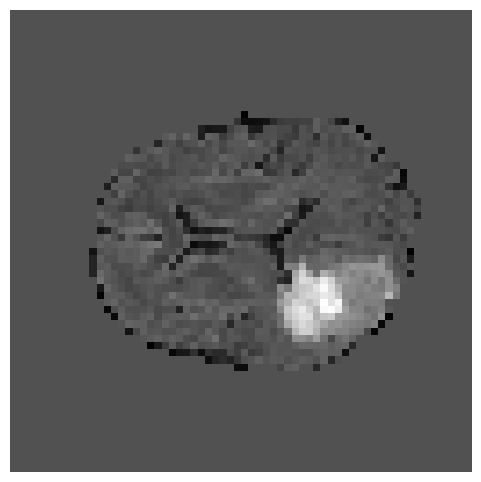

In [56]:
print(inputs.size())
show_tensor(inputs[0, :, :, 16])

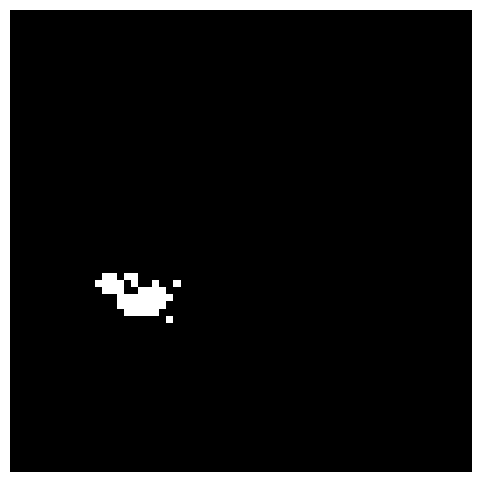

In [44]:
show_tensor(labels[2, :, :, 16])

In [79]:
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Test Single Run

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure previous model and tensors are explicitly deleted to free GPU memory
if 'model' in locals() and model is not None:
    del model
torch.cuda.empty_cache()

model = U_Transformer_DS(1, 3).to(device)
batch_data = train_ds[0]
scaler = torch.cuda.amp.GradScaler()  # Re-enabled for mixed precision
# enable cuDNN benchmark
torch.backends.cudnn.benchmark = True
inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
# Removed hardcoded reshape; model expects inputs for each modality to be 1 channel, handled internally
# The U_Transformer's forward method expects an input of shape (batch, modalities, H, W, D)
# Then it internally reshapes for each encoder.
# The DataLoader already provides batches with the correct shapes after transformations.
# For batch_size=1, inputs will be (1, 4, 224, 224, 144) and labels will be (1, 3, 224, 224, 144).
print(inputs.size())
print(labels.size())

inputs = inputs.resize(1, 4, 64, 64, 32)
labels = labels.resize(1, 3, 64, 64, 32)

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-5)
#lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")


model.train()
epoch_loss = 0
step = 0
step_start = time.time()
with torch.profiler.profile(
            activities=[
                torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA,
            ],
            #schedule=torch.profiler.schedule(wait=1, warmup=1, active=3),
            on_trace_ready=torch.profiler.tensorboard_trace_handler('./log/profile'),
            with_stack=True
        ) as prof:
  with torch.cuda.amp.autocast():  # Re-enabled AMP
      outputs = model(inputs)
      loss = loss_function(outputs, labels)

  scaler.scale(loss).backward()  # Re-enabled scaler
  scaler.step(optimizer)  # Re-enabled scaler
  scaler.update()  # Re-enabled scaler
  #loss.backward()
  #optimizer.step()

  epoch_loss += loss.item()
  print(
      f"{step}/{len(train_ds)}"
      f", train_loss: {loss.item():.4f}"
      f", step time: {(time.time() - step_start):.4f}"
  )
              #prof.step()

  #print('outputs', outputs.shape)

OutOfMemoryError: CUDA out of memory. Tried to allocate 28.00 MiB. GPU 0 has a total capacity of 94.97 GiB of which 23.88 MiB is free. Including non-PyTorch memory, this process has 94.94 GiB memory in use. Of the allocated memory 94.16 GiB is allocated by PyTorch, and 61.61 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
loss

# Batch Train

In [26]:
from itertools import combinations

MODALITIES = [0, 1, 2, 3]
SUBSETS = [list(s) for r in range(1, 5) for s in combinations(MODALITIES, r)]  # all non-empty subsets

def KL_divergence(mu_1, logvar_1, mu_2, logvar_2):
    """KLD(p_1 || p_2)"""
    var_1 = torch.exp(logvar_1)
    var_2 = torch.exp(logvar_2)
    KLD = 0.5 * torch.mean(-1 + logvar_2 - logvar_1 + (var_1 + (mu_1 - mu_2)**2) / (var_2 + 1e-7))
    
    return KLD


def Product_Gaussian(means, logvars, subset):
    eps = 1e-7
    mu_prior = torch.zeros_like(means[0])
    log_prior = torch.zeros_like(means[0])

    T = [1 / (torch.exp(logvars[i]) + eps) for i in subset] + [1 + log_prior]
    mu = [means[i] / (torch.exp(logvars[i]) + eps) for i in subset] + [mu_prior]

    T_sum = torch.stack(T).sum(dim=0)
    mu_sum = torch.stack(mu).sum(dim=0)

    posterior_means = mu_sum / T_sum
    var = 1 / T_sum
    posterior_logvars = torch.log(var + eps)
    posterior_logvars = torch.clamp(posterior_logvars, min=-10, max=10)

    return posterior_means, posterior_logvars


def compute_KLD(means, logvars):
    """
    means:   list of 4 tensors, one per modality
    logvars: list of 4 tensors, one per modality
    """
    assert len(means) == len(logvars) == 4

    mu_prior = torch.zeros_like(means[0])
    log_prior = torch.zeros_like(means[0])

    full_means, full_logvars = Product_Gaussian(means, logvars, MODALITIES)
    full_logvars = torch.clamp(full_logvars, min=-10, max=10)

    sum_inter_KLD = 0
    sum_prior_KLD = 0

    for subset in SUBSETS:
        sub_means, sub_logvars = Product_Gaussian(means, logvars, subset)

        sum_inter_KLD += KL_divergence(full_means, full_logvars, sub_means, sub_logvars)
        sum_prior_KLD += KL_divergence(sub_means, sub_logvars, mu_prior, log_prior)

    prior = torch.clamp(sum_prior_KLD, min=0.5)

    return sum_inter_KLD / 14, sum_prior_KLD / 15

In [27]:
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).

    """

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

In [28]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        #DownSample(keys=["image", "label"]),
        #Resized(
        #    keys=["image", "label"],
        #    spatial_size=(64, 64, 32),
        #    mode=("trilinear", "nearest")
        #),
        RandSpatialCropd(keys=["image", "label"], roi_size=[224, 224, 144], random_size=False), # Reverted ROI size
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
    ]
)

val_transform = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        #Resized(
        #    keys=["image", "label"],
        #    spatial_size=(64, 64, 32),
        #    mode=("trilinear", "nearest")
        #),
        # Add RandSpatialCropd for validation to ensure consistent input size
        #DownSample(keys=["image", "label"]),
        RandSpatialCropd(keys=["image", "label"], roi_size=[224, 224, 144], random_size=False), # Reverted ROI size
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ]
)

In [29]:
train_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    transform=train_transform,
    section="training",
    download=False,
    cache_rate=0.0,
    num_workers=0,
)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)
val_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    transform=val_transform,
    section="validation",
    download=False,
    cache_rate=0.0,
    num_workers=0,
)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=0)

In [32]:
max_epochs = 100
val_interval = 1
VAL_AMP = True

device = torch.device("cuda:0")
model = U_Transformer_VAE_DS(1, 3, batch_size=10).to(device)

model_weight_dir = '/mnt/monai-data/model_weights'

state_dict = torch.load(os.path.join(model_weight_dir, 'best_metric_model_vae_kl_anneal.pth'), weights_only=True)
model.load_state_dict(state_dict)


loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-5, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])


# define inference method
def inference(input, ds=False):
    def _compute(input):
        return sliding_window_inference(
            inputs=input,
            roi_size=(224, 224, 144) if not ds else (64, 64, 32), # Reverted to match original training crop size
            sw_batch_size=2,
            predictor=model,
            overlap=0.5,
        )

    if VAL_AMP:
        with torch.autocast("cuda"):
            return _compute(input)
    else:
        return _compute(input)


# use amp to accelerate training
scaler = torch.GradScaler("cuda")
# enable cuDNN benchmark
torch.backends.cudnn.benchmark = True

def kl_weight(epoch, warmup_epochs=100, max_weight=0.01):
    # also lower the max weight given the scale imbalance
    return max_weight * min(1.0, epoch / warmup_epochs)

In [31]:
import pickle

# Combine all lists into a dictionary for easier saving
def save_metrics(suffix, epoch_loss_values, metric_values, 
                 metric_values_tc, metric_values_wt, 
                 metric_values_et, epoch_val_losses,
                epoch_dice_loss_values):
    metrics_dir = "/mnt/monai-data/metrics"
    metrics_data = {
        'epoch_loss_values': epoch_loss_values,
        'epoch_val_losses': epoch_val_losses,
        'epoch_dice_loss_values': epoch_dice_loss_values,
        'metric_values': metric_values,
        'metric_values_tc': metric_values_tc,
        'metric_values_wt': metric_values_wt,
        'metric_values_et': metric_values_et,
    }
    
    # Define the filename to save the pickled data
    filename = os.path.join(metrics_dir, f"training_metrics_{suffix}.pkl")
    
    # Save the dictionary to a file using pickle
    with open(filename, 'wb') as f:
        pickle.dump(metrics_data, f)
    
    print(f"Training metrics saved to {filename}")

In [ ]:


best_metric = 0.7661
best_metric_epoch = -1
best_metrics_epochs_and_time = [[], [], []]
epoch_val_losses = []
epoch_loss_values = []
epoch_dice_loss_values = []
metric_values = []
metric_values_tc = []
metric_values_wt = []
metric_values_et = []



#set-up model
device = torch.device("cuda:0")
#model = U_Transformer(1, 3).to(device)
torch.cuda.empty_cache()

# Re-initialize optimizer, loss function, metrics, and scaler after model setup
loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-5, weight_decay=1e-5)
ce = nn.CrossEntropyLoss()
# lr_scheduler is also defined in 1SiHZ1k9PEwo, re-initialize for consistency if needed, but not directly causing this error.
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")
scaler = torch.GradScaler("cuda") # Re-initialize the scaler

total_start = time.time()
accum_iter = 10
for epoch in range(max_epochs):
    epoch_start = time.time()
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    epoch_dice_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()

        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )

        """with torch.profiler.profile(
            activities=[
                torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA,
            ],
            schedule=torch.profiler.schedule(wait=1, warmup=1, active=3),
            on_trace_ready=torch.profiler.tensorboard_trace_handler('./log/profile'),
            with_stack=True
        ) as prof:"""
        with torch.autocast("cuda"):
            outputs, level_params = model(inputs)
            kld = 0
            sum_inter_KLD = 0.0
            sum_prior_KLD = 0.0
            for i in range(3):
                means = level_params[i]['mu']
                log_var = level_params[i]['log_var']
                inter_KLD, prior_KLD = compute_KLD(means, log_var)
                sum_inter_KLD += inter_KLD
                sum_prior_KLD += prior_KLD
                
            kld = 1 / 4 * sum_inter_KLD + 1 / 4 * sum_prior_KLD
            dice_loss = loss_function(outputs, labels)
            ce_loss = ce(outputs, labels)
            loss = (dice_loss + ce_loss + kl_weight(epoch) * kld) / accum_iter

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * accum_iter
        epoch_dice_loss += dice_loss.item()

        if ((step + 1) % accum_iter == 0) or (step + 1 == len(train_loader)):
          scaler.step(optimizer)
          scaler.update()
          optimizer.zero_grad()


          print(
              f"{step}/{len(train_ds) // train_loader.batch_size}"
              f", train_loss: {(loss.item() * accum_iter):.4f}"
              f", step time: {(time.time() - step_start):.4f}"
          )

        step += 1
            #prof.step()

    lr_scheduler.step()
    epoch_loss /= step
    epoch_dice_loss /= step
    epoch_loss_values.append(epoch_loss)
    epoch_dice_loss_values.append(epoch_dice_loss)
    
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            val_losses = []
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                val_outputs_inf = inference(val_inputs)
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs_inf)]
                #dice_metric(y_pred=post_trans(val_outputs), y=val_labels)
                dice_metric(y_pred=val_outputs, y=val_labels)
                #dice_metric_batch(y_pred=post_trans(val_outputs), y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)
                #pred_y = model(val_inputs)
                val_losses.append(loss_function(val_outputs_inf, val_labels).item())
                
            epoch_val_losses.append(sum(val_losses) / len(val_losses))
            metric = dice_metric.aggregate().item()
            metric_values.append(metric)
            metric_batch = dice_metric_batch.aggregate()
            metric_tc = metric_batch[0].item()
            metric_values_tc.append(metric_tc)
            metric_wt = metric_batch[1].item()
            metric_values_wt.append(metric_wt)
            metric_et = metric_batch[2].item()
            metric_values_et.append(metric_et)
            dice_metric.reset()
            dice_metric_batch.reset()
            save_metrics(f"vae_ut_e{epoch}_kl_anneal_r13", epoch_loss_values, 
                         metric_values, metric_values_tc, metric_values_wt, metric_values_et,
                            epoch_val_losses, epoch_dice_loss_values)

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(
                    model.state_dict(),
                    os.path.join(model_weight_dir, "best_metric_model_vae_kl_anneal.pth"),
                )
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f" tc: {metric_tc:.4f} wt: {metric_wt:.4f} et: {metric_et:.4f}"
                f"\nbest mean dice: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
            
    torch.save(
                model.state_dict(),
                os.path.join(model_weight_dir, "latest_metric_model_vae_kl_anneal.pth"),
            )
    print(f"time consuming of epoch {epoch + 1} is: {(time.time() - epoch_start):.4f}")
total_time = time.time() - total_start

----------
epoch 1/100
9/194, train_loss: 0.2087, step time: 1.0451
19/194, train_loss: 0.1530, step time: 0.9678
29/194, train_loss: 0.1373, step time: 0.9590
39/194, train_loss: 0.1113, step time: 0.9630
49/194, train_loss: 0.1305, step time: 0.9588
59/194, train_loss: 0.1934, step time: 0.9603
69/194, train_loss: 0.1562, step time: 0.9584
79/194, train_loss: 0.2017, step time: 0.9609
89/194, train_loss: 0.1123, step time: 0.9593
99/194, train_loss: 0.1691, step time: 0.9593
109/194, train_loss: 0.1499, step time: 0.9596
119/194, train_loss: 0.1645, step time: 0.9626
129/194, train_loss: 0.3760, step time: 0.9588
139/194, train_loss: 0.0849, step time: 0.9596
149/194, train_loss: 0.1397, step time: 0.9591
159/194, train_loss: 0.1300, step time: 0.9870
169/194, train_loss: 0.1811, step time: 0.9597
179/194, train_loss: 0.2025, step time: 0.9667
189/194, train_loss: 0.0875, step time: 0.9707
193/194, train_loss: 0.1966, step time: 0.9600
epoch 1 average loss: 0.1801


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)


Training metrics saved to /mnt/monai-data/metrics/training_metrics_vae_ut_e0_kl_anneal_r13.pkl
current epoch: 1 current mean dice: 0.7482 tc: 0.8023 wt: 0.8768 et: 0.5656
best mean dice: 0.7661 at epoch: -1
time consuming of epoch 1 is: 857.7315
----------
epoch 2/100
9/194, train_loss: 0.1171, step time: 0.9594
19/194, train_loss: 0.1573, step time: 0.9589
29/194, train_loss: 0.1850, step time: 0.9592
39/194, train_loss: 0.1245, step time: 0.9601
49/194, train_loss: 0.1713, step time: 0.9589
59/194, train_loss: 0.2124, step time: 0.9849
69/194, train_loss: 0.1478, step time: 0.9752
79/194, train_loss: 0.3180, step time: 0.9620
89/194, train_loss: 0.1207, step time: 0.9628
99/194, train_loss: 0.1951, step time: 0.9607
109/194, train_loss: 0.2016, step time: 0.9597
119/194, train_loss: 0.1361, step time: 0.9726
129/194, train_loss: 0.1496, step time: 0.9592
139/194, train_loss: 0.1432, step time: 0.9593
149/194, train_loss: 0.2104, step time: 0.9601
159/194, train_loss: 0.1606, step tim

In [36]:
val_data = val_ds[0]
val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )

In [42]:
def inference(input, ds=False):
    def _compute(input):
        return sliding_window_inference(
            inputs=input,
            roi_size=(224, 224, 144) if not ds else (64, 64, 32), # Reverted to match original training crop size
            sw_batch_size=1,
            predictor=model,
            overlap=0.5,
        )

    if VAL_AMP:
        with torch.autocast("cuda"):
            return _compute(input)
    else:
        return _compute(input)

In [43]:
model.eval()
val_outputs_inf = inference(val_inputs.unsqueeze(0))
val_outputs = post_trans(val_outputs_inf)

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)


In [44]:
val_outputs.size()

torch.Size([1, 3, 224, 224, 144])

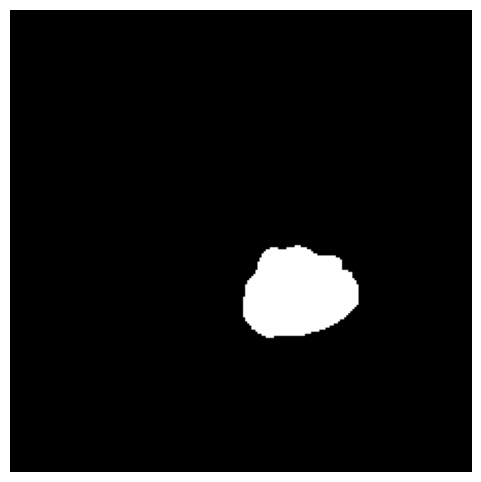

In [46]:
show_tensor(val_outputs[0, 0, :, :, 72])



In [56]:
import numpy as np
import matplotlib.patches as mpatches

def visualize_mosaic(I, P, L, alpha=0.4, save_path=None):
    """
    I: (4, H, W, D) - image tensor, first channel used
    P: (3, H, W, D) - prediction binary masks
    L: (3, H, W, D) - ground truth binary masks
    """
    d_slice = I.shape[-1] // 2

    img  = I[0, :, :, d_slice].cpu().float().numpy()
    pred = P[:, :, :, d_slice].cpu().float().numpy()
    gt   = L[:, :, :, d_slice].cpu().float().numpy()

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    colors = [
        [1.0, 0.2, 0.2],   # TC  — red
        [0.2, 1.0, 0.2],   # WT  — green
        [0.2, 0.6, 1.0],   # ET  — blue
    ]
    class_names = ['Tumor Core (TC)', 'Whole Tumor (WT)', 'Enhancing Tumor (ET)']

    def make_overlay(base_img, masks, class_idx=None):
        rgb = np.stack([base_img] * 3, axis=-1)
        indices = [class_idx] if class_idx is not None else range(len(colors))
        for c in indices:
            mask = masks[c].astype(bool)
            for ch in range(3):
                rgb[:, :, ch] = np.where(
                    mask,
                    (1 - alpha) * rgb[:, :, ch] + alpha * colors[c][ch],
                    rgb[:, :, ch]
                )
        return np.clip(rgb, 0, 1)

    def dice(p, g):
        intersection = (p * g).sum()
        return (2 * intersection / (p.sum() + g.sum() + 1e-8)).item()

    dice_scores = [dice(pred[c], gt[c]) for c in range(3)]

    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    fig.patch.set_facecolor('#1a1a1a')

    # ── Row 0: summary overlays ───────────────────────────────────────────
    row0 = [
        ('Image',        np.stack([img] * 3, axis=-1)),
        ('Ground truth', make_overlay(img, gt)),
        ('Prediction',   make_overlay(img, pred)),
    ]
    for ax, (title, overlay) in zip(axes[0], row0):
        ax.imshow(overlay, interpolation='nearest')
        ax.set_title(title, color='white', fontsize=18, pad=8)
        ax.axis('off')
        ax.set_facecolor('#1a1a1a')

    # ── Rows 1–2: per-class overlays ──────────────────────────────────────
    row_configs = [
        (axes[1], gt,   'GT'),
        (axes[2], pred, 'Pred'),
    ]
    for axes_row, masks, label in row_configs:
        for c, ax in enumerate(axes_row):
            overlay = make_overlay(img, masks, class_idx=c)
            ax.imshow(overlay, interpolation='nearest')
            ax.set_title(
                f'{label} — {class_names[c]}\ndice: {dice_scores[c]:.3f}',
                color='white', fontsize=18, pad=8
            )
            ax.axis('off')
            ax.set_facecolor('#1a1a1a')

    # ── Row labels ────────────────────────────────────────────────────────
    for ax, label in zip(axes[:, 0], ['Overview', 'GT per class', 'Pred per class']):
        ax.set_ylabel(label, color='#aaaaaa', fontsize=18, labelpad=8)

    # ── Legend ────────────────────────────────────────────────────────────
    patches = [
        mpatches.Patch(color=colors[c], label=f'{class_names[c]}  (dice: {dice_scores[c]:.3f})')
        for c in range(3)
    ]
    fig.legend(
        handles=patches,
        loc='lower center',
        ncol=3,
        fontsize=20,
        facecolor='#2a2a2a',
        edgecolor='#444',
        labelcolor='white',
        framealpha=1,
        bbox_to_anchor=(0.5, -0.03)
    )

    plt.suptitle(f'BraTS segmentation  |  slice d={d_slice}', color='white', fontsize=12, y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight',
                    facecolor=fig.get_facecolor(), dpi=150)

    plt.show()
    #return fig

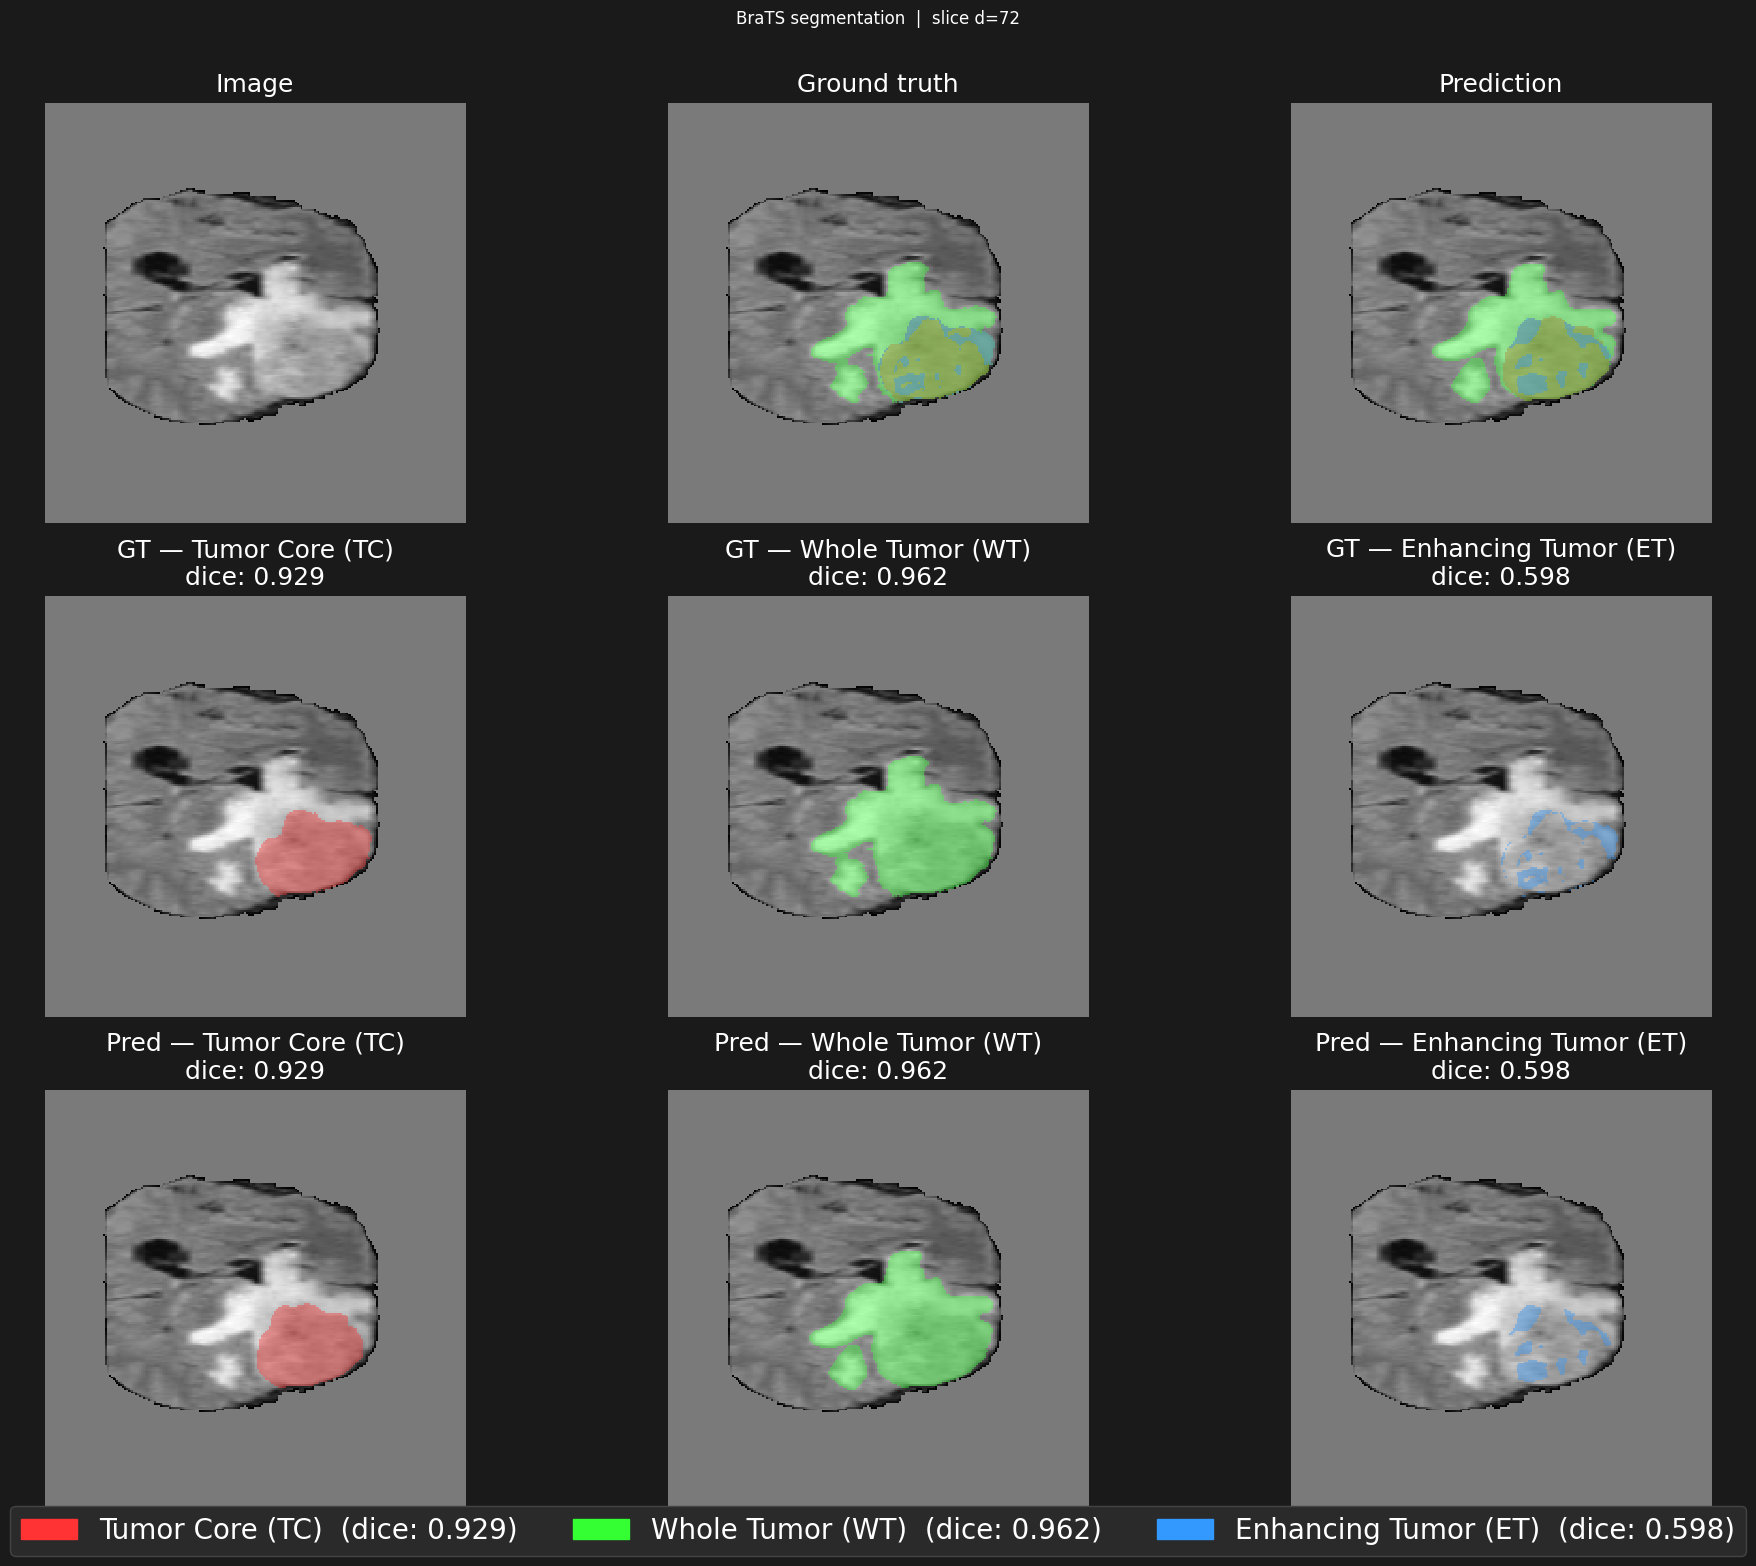

In [58]:
visualize_mosaic(val_inputs, val_outputs[0], val_labels, save_path='/mnt/monai-data/model_weights/vae_ut_mosai.png')

In [59]:
sum(p.numel() for p in model.parameters())

4719965